Importacao de Bibliotecas e Carregamento dos Dados

In [234]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

# Carregamento dos dados
df_events = pd.read_csv('final_ab_events_upd_us.csv')
df_users = pd.read_csv('final_ab_new_users_upd_us.csv')
df_participants = pd.read_csv('final_ab_participants_upd_us.csv')
df_marketing = pd.read_csv('ab_project_marketing_events_us.csv')


PRÉ PROCESSAMENTO DE DADOS

In [235]:
# df_events

df_events.describe()


,details
count,60314.000000
mean,23.881219
std,72.228884
min,4.990000
25%,4.990000
50%,4.990000
75%,9.990000
max,499.990000


In [236]:
print(df_events.shape)
df_events.info()
print(df_events.sample(15))

(423761, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB
                 user_id             event_dt    event_name  details
141158  BB9B865A5D2D0F64  2020-12-12 05:57:09  product_page      NaN
377539  8EE8F67CDEBC0743  2020-12-22 05:12:49         login      NaN
327730  0D0A66DBED70703D  2020-12-18 02:35:54         login      NaN
136603  812445837CFA8BDC  2020-12-11 05:15:16  product_page      NaN
294626  CA4BFA486A392D29  2020-12-14 21:24:50         login      NaN
154449  378A46A291B7ABAD  2020-12-14 07:03:38  product_page      NaN
412049  07E63B303EF8AC4F  2020-12-27 09:50:57         login      NaN
273614  FCE95208B6252

O df_events apresenta muitos NaNs em details, isso é causado por causa que nem todos clientes efetuaram uma compra

In [237]:
# df_users

df_users.describe()


,user_id,first_date,region,device
count,58703,58703,58703,58703
unique,58703,17,4,4
top,8F04273BB2860229,2020-12-21,EU,Android
freq,1,6077,43396,26159


In [238]:
print(df_users.shape)
df_users.info()
print(df_users.head(15))
print(df_users['device'].unique())

(58703, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB
             user_id  first_date     region   device
0   D72A72121175D8BE  2020-12-07         EU       PC
1   F1C668619DFE6E65  2020-12-07  N.America  Android
2   2E1BF1D4C37EA01F  2020-12-07         EU       PC
3   50734A22C0C63768  2020-12-07         EU   iPhone
4   E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone
5   137119F5A9E69421  2020-12-07  N.America   iPhone
6   62F0C741CC42D0CC  2020-12-07       APAC   iPhone
7   8942E64218C9A1ED  2020-12-07         EU       PC
8   499AFACF904BBAE3  2020-12-07  N.America   iPhone
9   FFCEA1179C253104  2020-12-07         EU  Android
10  5EB159DA9DC94D

A coluna DEVICE tem somente 4 possibilidades para 58mil entradas, vou substituir o dtype para categorico

In [239]:
# df_participants

df_participants.describe()


,user_id,group,ab_test
count,14525,14525,14525
unique,13638,2,2
top,FABB6D49B11E673F,A,interface_eu_test
freq,2,8214,10850


In [240]:
print(df_participants.shape)
df_participants.info()
print(df_participants.head(15))

(14525, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB
             user_id group                  ab_test
0   D1ABA3E2887B6A73     A  recommender_system_test
1   A7A3664BD6242119     A  recommender_system_test
2   DABC14FDDFADD29E     A  recommender_system_test
3   04988C5DF189632E     A  recommender_system_test
4   4FF2998A348C484F     A  recommender_system_test
5   7473E0943673C09E     A  recommender_system_test
6   C46FE336D240A054     A  recommender_system_test
7   92CB588012C10D3D     A  recommender_system_test
8   B3A2485649E4A012     A  recommender_system_test
9   66FC298441D50783     A  recommender_system_test
10  CD74C3D22FFC09C2     B  recommender_system_test
11  19F4A16B875E04EE     A  re

In [241]:
# df_marketing

df_marketing.describe()


,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Christmas&New Year Promo,APAC,2020-12-25,2021-01-03
freq,1,4,1,1


In [242]:
print(df_marketing.shape)
df_marketing.info()
print(df_marketing.head(15))

(14, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes
                                name                   regions    start_dt  \
0           Christmas&New Year Promo             EU, N.America  2020-12-25   
1       St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2             St. Patric's Day Promo             EU, N.America  2020-03-17   
3                       Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4                  4th of July Promo                 N.America  2020-07-04   
5          Black Friday Ads Campaign  EU, CIS, APAC, N.America  2020-11-26   
6             Chinese New Year Promo                      APAC  2

Conversao de Tipos de Dados

In [243]:
df_events['event_dt'] = pd.to_datetime(df_events['event_dt'])
df_users['first_date'] = pd.to_datetime(df_users['first_date'])
df_marketing['start_dt'] = pd.to_datetime(df_marketing['start_dt'])
df_marketing['finish_dt'] = pd.to_datetime(df_marketing['finish_dt'])
df_users['device'] = df_users['device'].astype('category')
df_events['event_name'] = df_events['event_name'].astype('category')

print(df_events['event_dt'].dtype)
print(df_users['first_date'].dtype)
print(df_users['device'].dtype)
print(df_events['event_name'].dtype)

datetime64[ns]
datetime64[ns]
category
category


Valores Ausentes e Duplicados

In [244]:
print('\nEventos:'); print(df_events.isnull().sum())
print('\nUsuarios:'); print(df_users.isnull().sum())
print('\nParticipantes:'); print(df_participants.isnull().sum())

#Há valores ausentes em details pois só é contabilizado valores aqueles que houve compras


Eventos:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Usuarios:
user_id       0
first_date    0
region        0
device        0
dtype: int64

Participantes:
user_id    0
group      0
ab_test    0
dtype: int64


In [245]:
#DUPLICADOS:
print(f'Eventos: {df_events.duplicated().sum()}')
print(f'Usuarios: {df_users.duplicated().sum()}')
print(f'Participantes: {df_participants.duplicated().sum()}')


Eventos: 0
Usuarios: 0
Participantes: 0


Distribuicao de Testes e Grupos

In [246]:
print('Testes na base de participantes:')
print(df_participants['ab_test'].value_counts())

print('\nGrupos por teste:')
print(df_participants.groupby(['ab_test', 'group']).size().unstack(fill_value=0))


Testes na base de participantes:
ab_test
interface_eu_test          10850
recommender_system_test     3675
Name: count, dtype: int64

Grupos por teste:
group                       A     B
ab_test                            
interface_eu_test        5467  5383
recommender_system_test  2747   928


Verificar se há usuarios nos dois grupos

In [247]:
df_participants['user_id'].value_counts()

user_id
FABB6D49B11E673F    2
4F26C1C82B9EA0B5    2
40194A2E6C03B547    2
7C91912332353320    2
DABC14FDDFADD29E    2
                   ..
1A2AB676972C78ED    1
1122B6A73F458648    1
9A542FC70F23E574    1
03C42F418617D45E    1
1F7B341114789120    1
Name: count, Length: 13638, dtype: int64

In [248]:
duplicados = df_participants['user_id'].value_counts()
duplicados = duplicados[duplicados > 1].index

df_participants = df_participants[~df_participants['user_id'].isin(duplicados)]

print(df_participants.shape)

(12751, 3)


Filtrar somente para usuários da região EU

In [249]:
df_participants_eu = pd.merge(df_participants, df_users, on='user_id', how='left')
print(df_participants_eu.sample(10))

               user_id group                  ab_test first_date     region  \
5244  DBE3C5B4DC0F7D86     B        interface_eu_test 2020-12-14         EU   
4123  19EC418F07C5B6E1     A        interface_eu_test 2020-12-11         EU   
1255  ACB0CDD5917A8DD5     A  recommender_system_test 2020-12-15         EU   
5305  96591A5EBAD9C7FF     A        interface_eu_test 2020-12-22         EU   
3166  40F288C6EDEEE6D9     B        interface_eu_test 2020-12-10         EU   
3759  A3FD28B9840F2021     B        interface_eu_test 2020-12-13         EU   
1555  77BD281B14AFB4A5     A  recommender_system_test 2020-12-21         EU   
2649  66E02518441F5E9C     A  recommender_system_test 2020-12-17  N.America   
9731  B1D0081735B0C6AD     A        interface_eu_test 2020-12-15         EU   
1449  FC7F311FE04AC405     A  recommender_system_test 2020-12-12         EU   

       device  
5244  Android  
4123  Android  
1255  Android  
5305  Android  
3166   iPhone  
3759  Android  
1555  Android  
26

In [250]:
df_participants_eu = df_participants_eu[df_participants_eu['region'] == 'EU']
df_participants_eu.shape

(12557, 6)

In [251]:
df_participants_eu_recomender = df_participants_eu[df_participants_eu['ab_test'] == 'recommender_system_test']
df_participants_eu_recomender.shape

(2594, 6)

Filtragem do DF_events para conter somentes os eventos dos usuários que estão no grupo de participantes

In [252]:
df_events_eu = df_events[df_events['user_id'].isin(df_participants_eu_recomender['user_id'])]
df_events_eu.shape

(16959, 4)

Verificar a distribuição de EVENTOS totais dos usuários ao longos dos dias

In [253]:
df_events_eu['event_dt'].dt.date.value_counts()

event_dt
2020-12-21    1750
2020-12-20    1337
2020-12-19    1316
2020-12-18    1108
2020-12-22    1090
2020-12-17    1069
2020-12-16    1023
2020-12-14     948
2020-12-15     944
2020-12-23     864
2020-12-24     742
2020-12-09     532
2020-12-27     513
2020-12-26     491
2020-12-07     489
2020-12-10     428
2020-12-12     423
2020-12-08     408
2020-12-28     395
2020-12-11     379
2020-12-29     372
2020-12-13     336
2020-12-30       2
Name: count, dtype: int64

Verificar porque dia 21/12 teve muito mais eventos que os outros dias

In [254]:
data = pd.Timestamp('2020-12-21').date()

df_marketing[
    (df_marketing['start_dt'].dt.date <= data) & 
    (df_marketing['finish_dt'].dt.date >= data)
]

,name,regions,start_dt,finish_dt


In [255]:
df_marketing

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11


Durante o período de 25/12 a 03/01/2021 havia uma campanha de marketing ativa na região EU e NA, o que pode inflar os dados para os dados obtidos dentro do período que pode afetar os reais resultados do experimento.

Juntar os dataframes participants e events para saber a qual grupo cada evento pertence

In [256]:
df_events_merge = df_events_eu.merge(df_participants_eu_recomender, on='user_id', how='left')
df_events_merge.head()

,user_id,event_dt,event_name,details,group,ab_test,first_date,region,device
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,recommender_system_test,2020-12-07,EU,Android
1,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,A,recommender_system_test,2020-12-07,EU,PC
2,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,B,recommender_system_test,2020-12-07,EU,iPhone
3,A640F31CAC7823A6,2020-12-07 18:48:26,purchase,4.99,B,recommender_system_test,2020-12-07,EU,PC
4,A9908F62C41613A8,2020-12-07 11:26:47,purchase,9.99,B,recommender_system_test,2020-12-07,EU,PC


Contagem de Eventos na coluna event_name para entender o funil de conversão

In [257]:
df_events_merge_gb = df_events_merge.groupby(['group', 'event_name'])['event_name'].count()
print(df_events_merge_gb)

group  event_name  
A      login           5876
       product_cart    1802
       product_page    3806
       purchase        1774
B      login           1781
       product_cart     489
       product_page     946
       purchase         485
Name: event_name, dtype: int64


C:\Users\gamer\AppData\Local\Temp\ipykernel_10160\2928375024.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_events_merge_gb = df_events_merge.groupby(['group', 'event_name'])['event_name'].count()


In [258]:
df_events_merge_unique = df_events_merge.groupby('group')['user_id'].nunique()
print(df_events_merge_unique)

group
A    1939
B     655
Name: user_id, dtype: int64


Calcular quantos usuários unicos fizeram cada ação em cada grupo.

In [259]:
df_events_group_unique = df_events_merge.groupby(['group', 'event_name'], observed=True)['user_id'].nunique()
print(df_events_group_unique)

group  event_name  
A      login           1939
       product_cart     589
       product_page    1265
       purchase         613
B      login            654
       product_cart     184
       product_page     367
       purchase         191
Name: user_id, dtype: int64


Calcular a taxa de conversão de cada usuário para a etapa seguinte

In [260]:
df_events_group_unique_reset = df_events_group_unique.reset_index()

df_group_pivot = df_events_group_unique_reset.pivot(index='event_name', columns='group', values='user_id')

#Reordenar o funil
ordem_funil = ['product_page', 'product_cart', 'purchase']

df_group_pivot = df_group_pivot.loc[ordem_funil]

print(df_group_pivot)

group            A    B
event_name             
product_page  1265  367
product_cart   589  184
purchase       613  191


In [261]:
#Grupo A

df_group_pivot['conv_A'] = df_group_pivot['A'] / df_group_pivot.loc['product_page', 'A']
df_group_pivot['conv_A'] = (df_group_pivot['conv_A'] * 100).round(2)

#Grupo B

df_group_pivot['conv_B'] = df_group_pivot['B'] / df_group_pivot.loc['product_page', 'B']
df_group_pivot['conv_B'] = (df_group_pivot['conv_B'] * 100).round(2)

print(df_group_pivot)

group            A    B  conv_A  conv_B
event_name                             
product_page  1265  367  100.00  100.00
product_cart   589  184   46.56   50.14
purchase       613  191   48.46   52.04


Calcular a diferença percentual entre cada grupo

In [262]:
df_group_pivot['conv_diff'] = df_group_pivot['conv_B'] - df_group_pivot['conv_A']
print(df_group_pivot)

group            A    B  conv_A  conv_B  conv_diff
event_name                                        
product_page  1265  367  100.00  100.00       0.00
product_cart   589  184   46.56   50.14       3.58
purchase       613  191   48.46   52.04       3.58


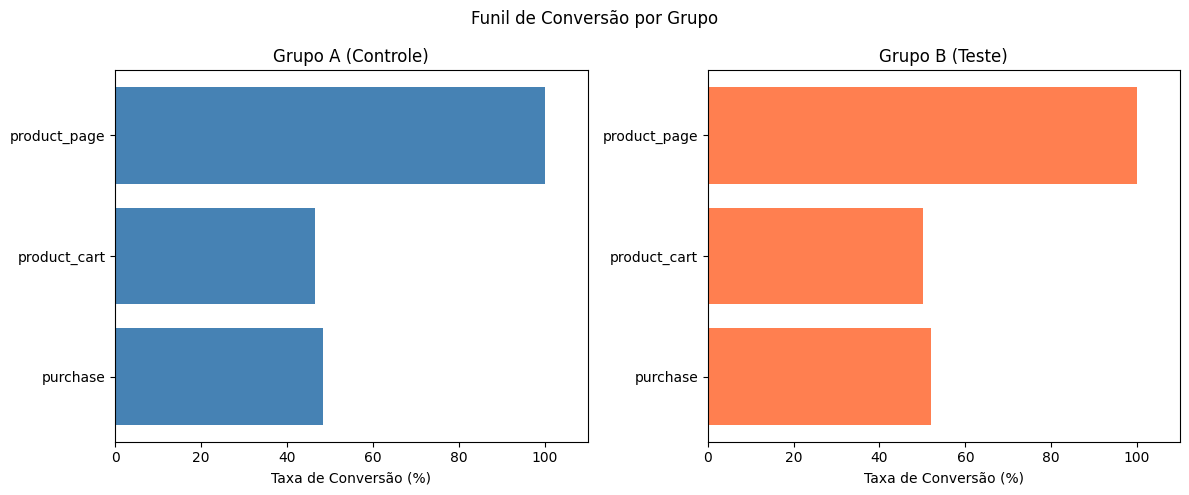

In [263]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

etapas = ['product_page', 'product_cart', 'purchase']
conv_A = df_group_pivot.loc[etapas, 'conv_A']
conv_B = df_group_pivot.loc[etapas, 'conv_B']

# Grupo A
ax1.barh(etapas, conv_A, color='steelblue')
ax1.invert_yaxis()
ax1.set_xlabel('Taxa de Conversão (%)')
ax1.set_title('Grupo A (Controle)')
ax1.set_xlim(0, 110)

# Grupo B
ax2.barh(etapas, conv_B, color='coral')
ax2.invert_yaxis()
ax2.set_xlabel('Taxa de Conversão (%)')
ax2.set_title('Grupo B (Teste)')
ax2.set_xlim(0, 110)

plt.suptitle('Funil de Conversão por Grupo')
plt.tight_layout()
plt.show()